In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
df = pd.read_csv('diabetic_data.csv')
df.replace('?', np.nan, inplace=True)

print(f"Dataset shape: {df.shape}")
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
df.head()

Dataset shape: (101766, 50)
Rows: 101,766  |  Columns: 50


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [3]:
numerical_cols = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'number_diagnoses'
]

desc_stats = df[numerical_cols].describe().T
desc_stats['skewness'] = df[numerical_cols].skew()
desc_stats['kurtosis'] = df[numerical_cols].kurt()

print("=== Descriptive Statistics for Numerical Features ===")
desc_stats.round(2)

=== Descriptive Statistics for Numerical Features ===


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
time_in_hospital,101766.0,4.40,2.99,1.0,2.0,4.0,6.0,14.0,1.13,0.85
num_lab_procedures,101766.0,43.10,19.67,1.0,31.0,44.0,57.0,132.0,-0.24,-0.25
num_procedures,101766.0,1.34,1.71,0.0,0.0,1.0,2.0,6.0,1.32,0.86
num_medications,101766.0,16.02,8.13,1.0,10.0,15.0,20.0,81.0,1.33,3.47
number_outpatient,101766.0,0.37,1.27,0.0,0.0,0.0,0.0,42.0,8.83,147.91
number_emergency,101766.0,0.20,0.93,0.0,0.0,0.0,0.0,76.0,22.86,1191.69
number_inpatient,101766.0,0.64,1.26,0.0,0.0,0.0,1.0,21.0,3.61,20.72
number_diagnoses,101766.0,7.42,1.93,1.0,6.0,8.0,9.0,16.0,-0.88,-0.08


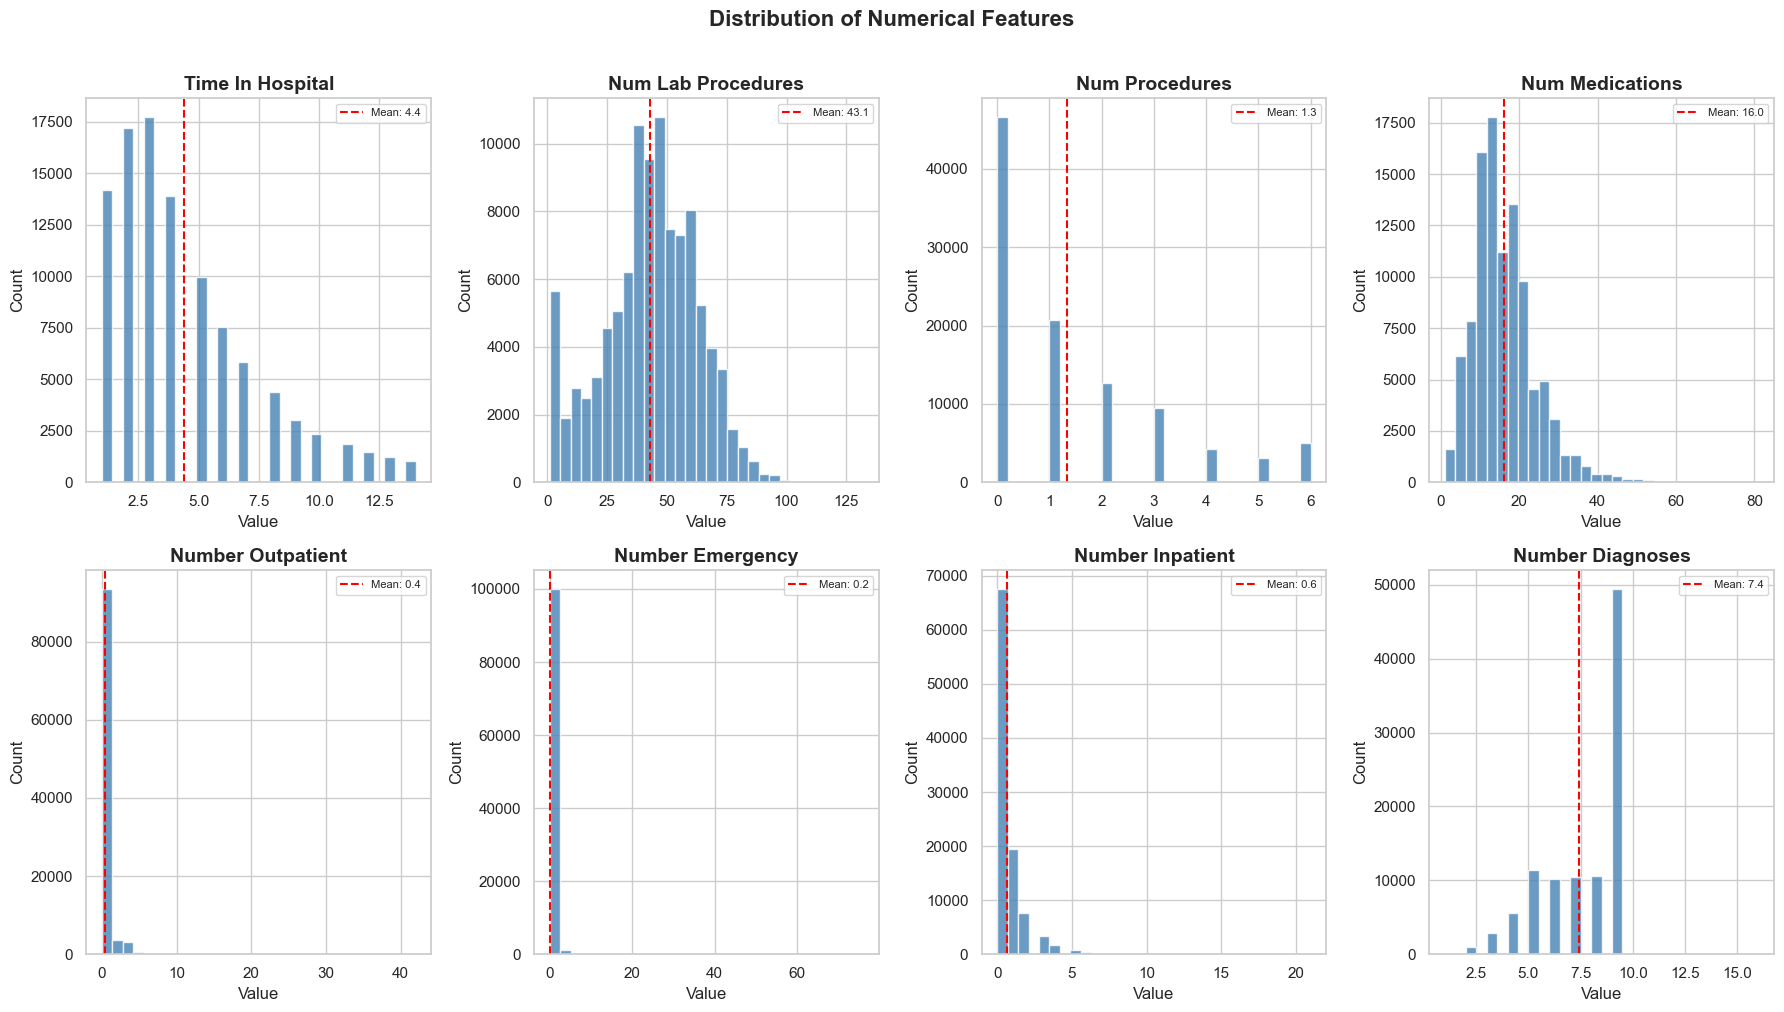

Saved: numerical_distributions.png


In [4]:
# Cell 4: Visualize distributions of key numerical features
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col.replace('_', ' ').title())
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    mean_val = df[col].mean()
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.1f}')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: numerical_distributions.png")

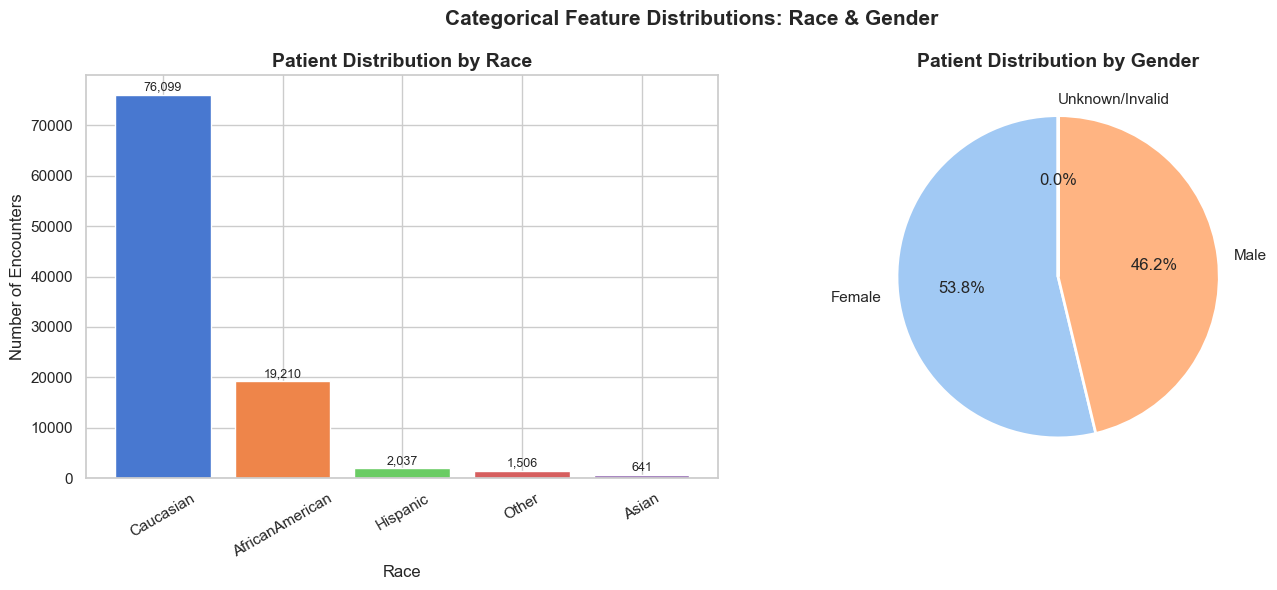

Saved: race_gender_distribution.png


In [5]:
# Cell 5: Race distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Race
race_counts = df['race'].value_counts()
bars = axes[0].bar(race_counts.index, race_counts.values,
                   color=sns.color_palette('muted', len(race_counts)))
axes[0].set_title('Patient Distribution by Race')
axes[0].set_xlabel('Race')
axes[0].set_ylabel('Number of Encounters')
axes[0].tick_params(axis='x', rotation=30)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)

# Gender
gender_counts = df['gender'].value_counts()
axes[1].pie(gender_counts.values,
            labels=gender_counts.index,
            autopct='%1.1f%%',
            colors=sns.color_palette('pastel'),
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Patient Distribution by Gender')

plt.suptitle('Categorical Feature Distributions: Race & Gender',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('race_gender_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: race_gender_distribution.png")

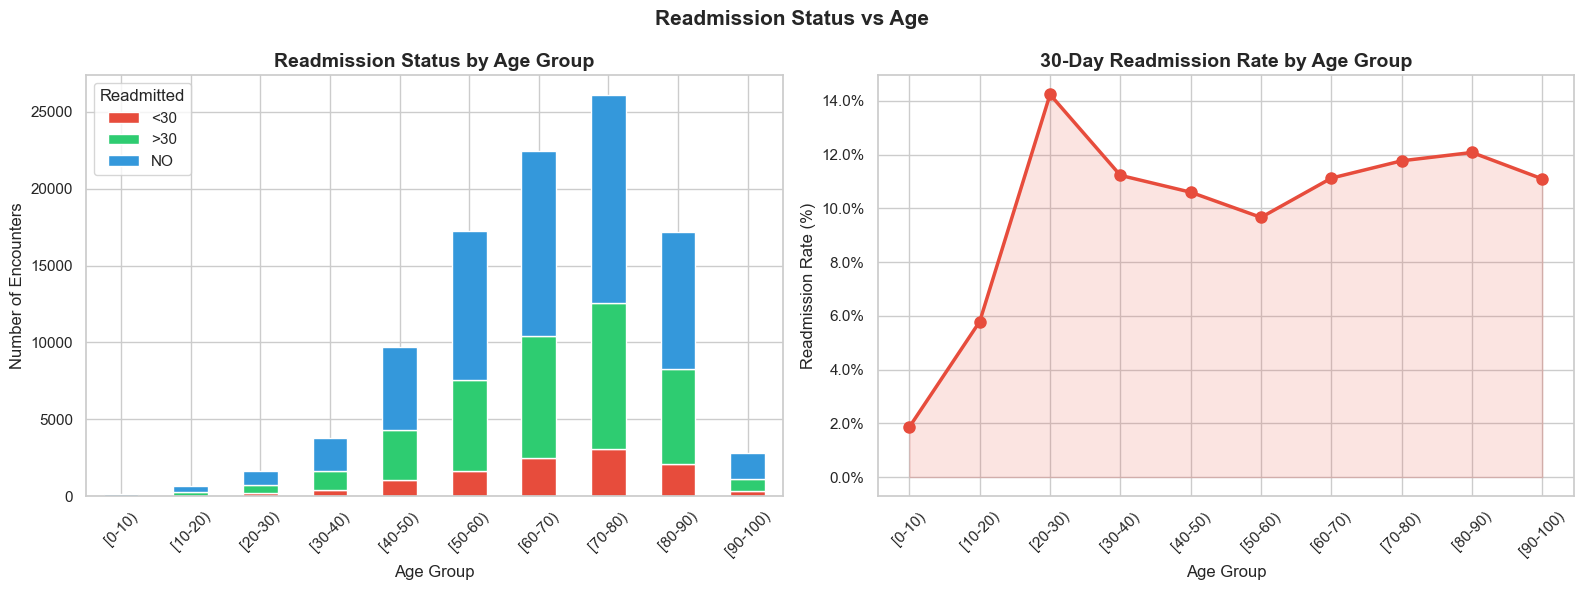

Saved: readmission_vs_age.png


In [6]:
# Cell 6: Readmission status across age groups
age_order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
             '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']

age_readmit = (df.groupby(['age', 'readmitted'])
                 .size()
                 .reset_index(name='count'))

# Filter to valid age groups only
age_readmit = age_readmit[age_readmit['age'].isin(age_order)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Stacked bar chart
pivot = age_readmit.pivot(index='age', columns='readmitted', values='count').fillna(0)
pivot = pivot.reindex(age_order)
pivot.plot(kind='bar', stacked=True, ax=axes[0],
           color=['#e74c3c', '#2ecc71', '#3498db'], edgecolor='white')
axes[0].set_title('Readmission Status by Age Group')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Number of Encounters')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Readmitted', loc='upper left')

# 30-day readmission rate by age
readmit_rate = (df.groupby('age')
                  .apply(lambda x: (x['readmitted'] == '<30').sum() / len(x) * 100)
                  .reset_index(name='readmission_rate_pct'))
readmit_rate = readmit_rate[readmit_rate['age'].isin(age_order)]
readmit_rate['age'] = pd.Categorical(readmit_rate['age'], categories=age_order, ordered=True)
readmit_rate = readmit_rate.sort_values('age')

axes[1].plot(readmit_rate['age'], readmit_rate['readmission_rate_pct'],
             marker='o', color='#e74c3c', linewidth=2.5, markersize=8)
axes[1].fill_between(range(len(readmit_rate)), readmit_rate['readmission_rate_pct'],
                     alpha=0.15, color='#e74c3c')
axes[1].set_xticks(range(len(readmit_rate)))
axes[1].set_xticklabels(readmit_rate['age'], rotation=45)
axes[1].set_title('30-Day Readmission Rate by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Readmission Rate (%)')
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))

plt.suptitle('Readmission Status vs Age', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('readmission_vs_age.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: readmission_vs_age.png")

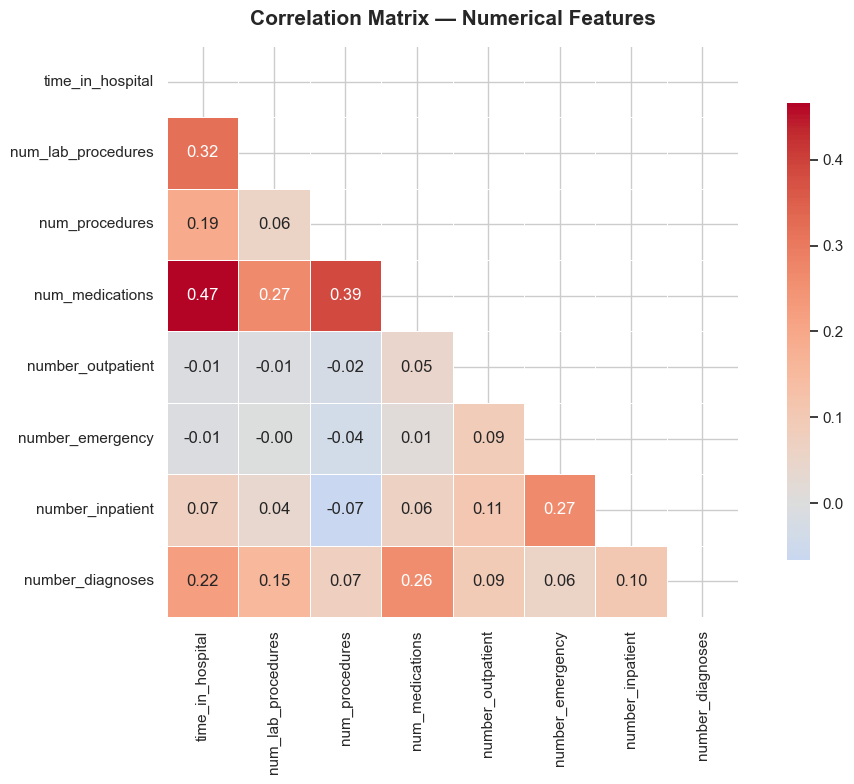

Saved: correlation_heatmap.png

=== Top 5 Strongest Correlations ===
         Feature 1          Feature 2  Correlation
   num_medications   time_in_hospital     0.466135
   num_medications     num_procedures     0.385767
num_lab_procedures   time_in_hospital     0.318450
   num_medications num_lab_procedures     0.268161
  number_inpatient   number_emergency     0.266559


In [7]:
# Cell 7: Correlation heatmap
corr_matrix = df[numerical_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle

sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={'shrink': 0.8},
            ax=ax)

ax.set_title('Correlation Matrix — Numerical Features', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: correlation_heatmap.png")

# Print top correlations
print("\n=== Top 5 Strongest Correlations ===")
corr_pairs = (corr_matrix.where(mask == False)
                          .stack()
                          .reset_index())
corr_pairs.columns = ['Feature 1', 'Feature 2', 'Correlation']
corr_pairs['abs_corr'] = corr_pairs['Correlation'].abs()
print(corr_pairs[corr_pairs['Feature 1'] != corr_pairs['Feature 2']]
      .sort_values('abs_corr', ascending=False)
      .head(5)[['Feature 1', 'Feature 2', 'Correlation']]
      .to_string(index=False))

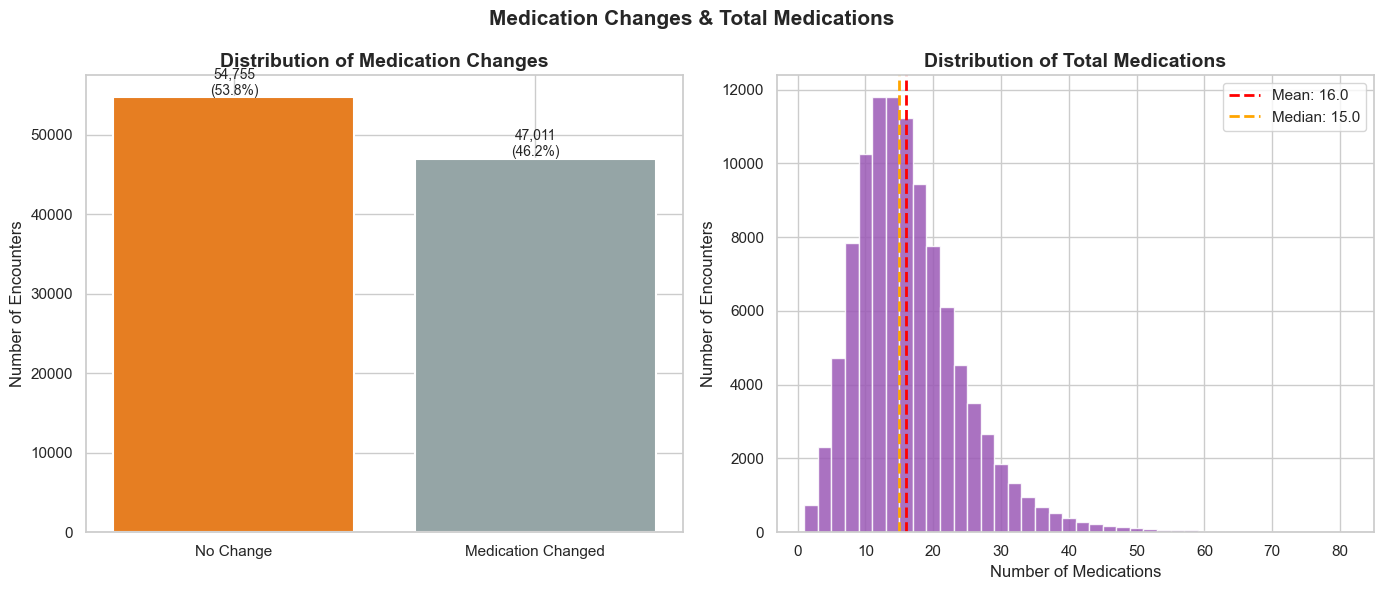

Saved: medication_analysis.png


In [8]:
# Cell 8: Distribution of medication changes
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Medication change (change column: Ch = changed, No = not changed)
change_counts = df['change'].value_counts()
change_labels = {'Ch': 'Medication Changed', 'No': 'No Change'}
change_counts.index = [change_labels.get(i, i) for i in change_counts.index]

axes[0].bar(change_counts.index, change_counts.values,
            color=['#e67e22', '#95a5a6'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribution of Medication Changes')
axes[0].set_ylabel('Number of Encounters')
for i, v in enumerate(change_counts.values):
    axes[0].text(i, v + 300, f'{v:,}\n({v/len(df)*100:.1f}%)',
                 ha='center', fontsize=10)

# Total medications distribution
axes[1].hist(df['num_medications'].dropna(), bins=40,
             color='#9b59b6', edgecolor='white', alpha=0.85)
axes[1].axvline(df['num_medications'].mean(), color='red', linestyle='--',
                linewidth=2, label=f"Mean: {df['num_medications'].mean():.1f}")
axes[1].axvline(df['num_medications'].median(), color='orange', linestyle='--',
                linewidth=2, label=f"Median: {df['num_medications'].median():.1f}")
axes[1].set_title('Distribution of Total Medications')
axes[1].set_xlabel('Number of Medications')
axes[1].set_ylabel('Number of Encounters')
axes[1].legend()

plt.suptitle('Medication Changes & Total Medications', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('medication_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: medication_analysis.png")

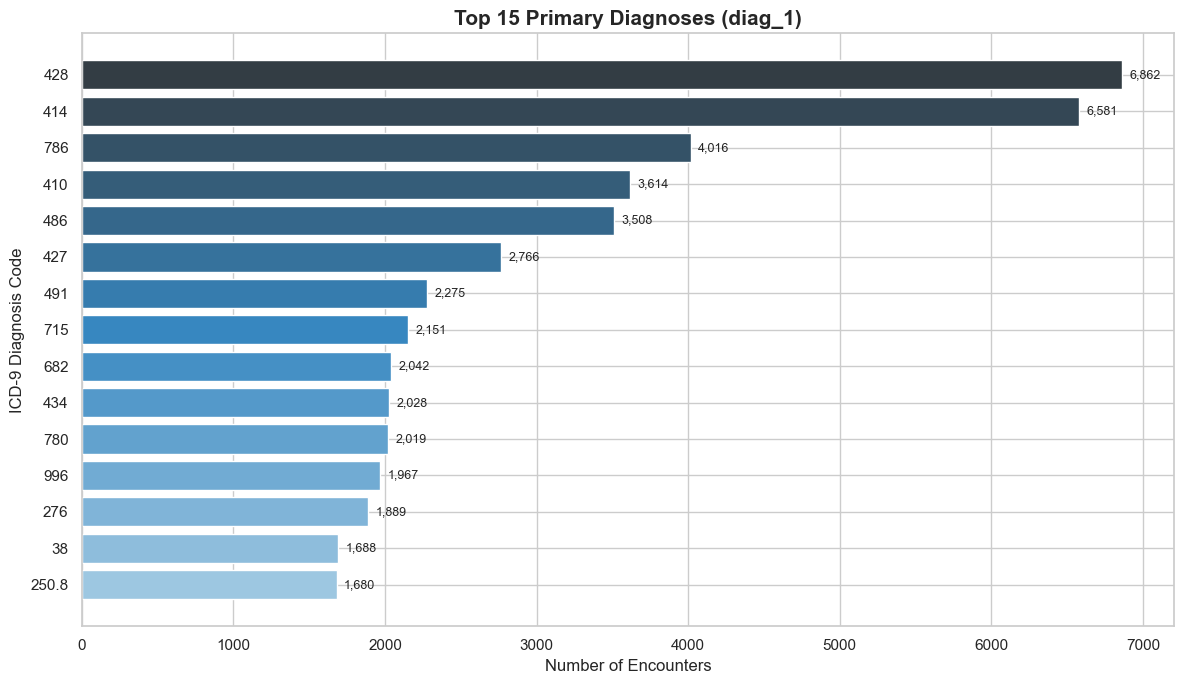

Saved: diagnoses_distribution.png


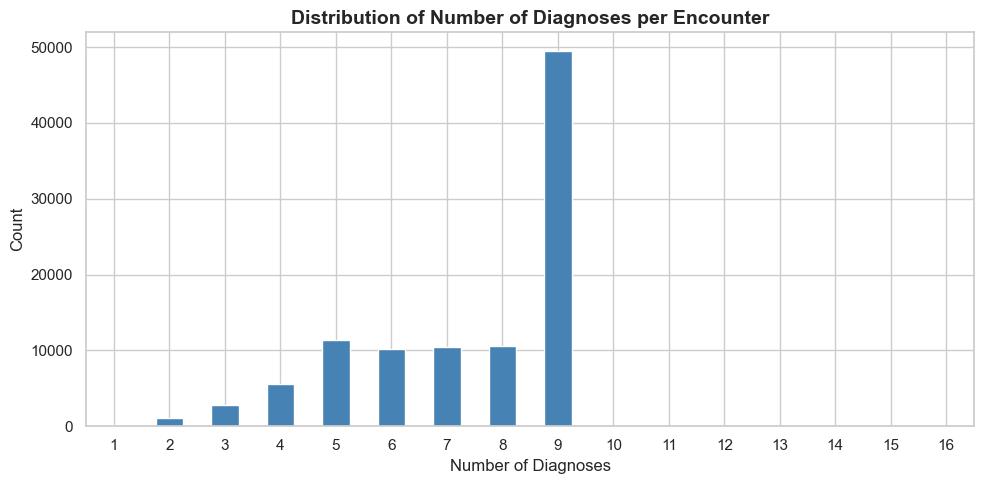

Saved: number_diagnoses.png


In [9]:
# Cell 9: Top 15 primary diagnoses
top_diag = (df['diag_1'].dropna()
              .value_counts()
              .head(15)
              .reset_index())
top_diag.columns = ['diagnosis_code', 'count']

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top_diag['diagnosis_code'][::-1], top_diag['count'][::-1],
               color=sns.color_palette('Blues_d', 15))
ax.set_title('Top 15 Primary Diagnoses (diag_1)', fontsize=15, fontweight='bold')
ax.set_xlabel('Number of Encounters')
ax.set_ylabel('ICD-9 Diagnosis Code')
for bar in bars:
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width()):,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('diagnoses_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: diagnoses_distribution.png")

# Number of diagnoses distribution
fig, ax = plt.subplots(figsize=(10, 5))
df['number_diagnoses'].value_counts().sort_index().plot(kind='bar', ax=ax,
    color='steelblue', edgecolor='white')
ax.set_title('Distribution of Number of Diagnoses per Encounter')
ax.set_xlabel('Number of Diagnoses')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('number_diagnoses.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: number_diagnoses.png")

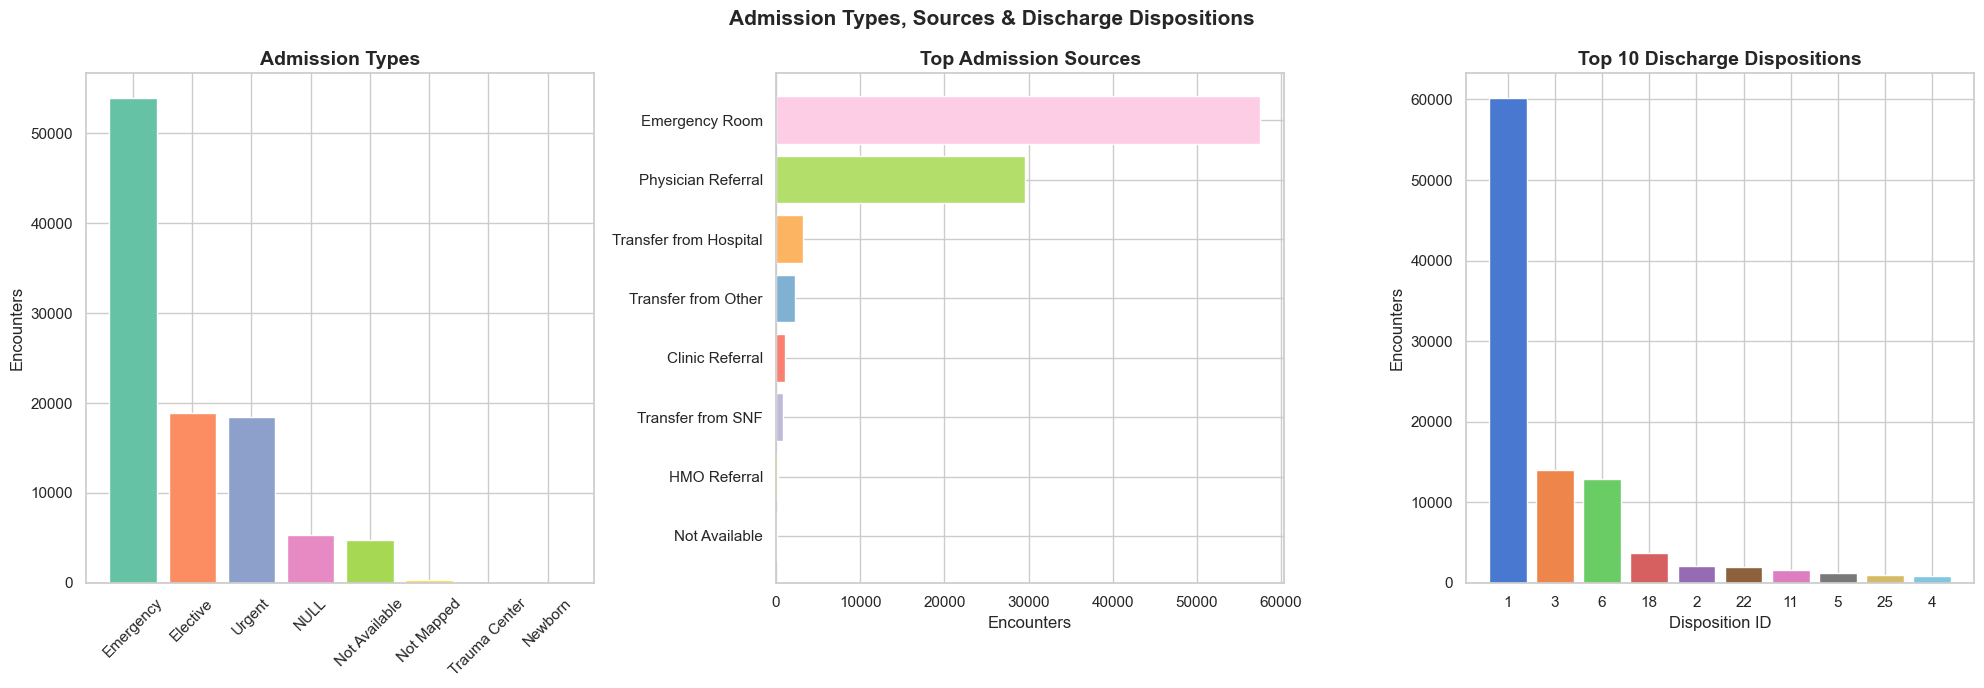

Saved: admission_discharge.png


In [10]:
# Cell 10: Admission type labels
admission_type_map = {
    1: 'Emergency', 2: 'Urgent', 3: 'Elective',
    4: 'Newborn', 5: 'Not Available', 6: 'NULL',
    7: 'Trauma Center', 8: 'Not Mapped'
}
admission_source_map = {
    1: 'Physician Referral', 2: 'Clinic Referral', 3: 'HMO Referral',
    4: 'Transfer from Hospital', 5: 'Transfer from SNF',
    6: 'Transfer from Other', 7: 'Emergency Room',
    8: 'Court/Law Enforcement', 9: 'Not Available'
}

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# Admission Type
at = df['admission_type_id'].map(admission_type_map).value_counts()
axes[0].bar(at.index, at.values, color=sns.color_palette('Set2', len(at)))
axes[0].set_title('Admission Types')
axes[0].set_ylabel('Encounters')
axes[0].tick_params(axis='x', rotation=45)

# Admission Source (top 8)
as_ = df['admission_source_id'].map(admission_source_map).value_counts().head(8)
axes[1].barh(as_.index[::-1], as_.values[::-1],
             color=sns.color_palette('Set3', len(as_)))
axes[1].set_title('Top Admission Sources')
axes[1].set_xlabel('Encounters')

# Discharge Disposition (top 10)
dd = df['discharge_disposition_id'].value_counts().head(10)
axes[2].bar(dd.index.astype(str), dd.values,
            color=sns.color_palette('muted', len(dd)))
axes[2].set_title('Top 10 Discharge Dispositions')
axes[2].set_xlabel('Disposition ID')
axes[2].set_ylabel('Encounters')

plt.suptitle('Admission Types, Sources & Discharge Dispositions',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('admission_discharge.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: admission_discharge.png")

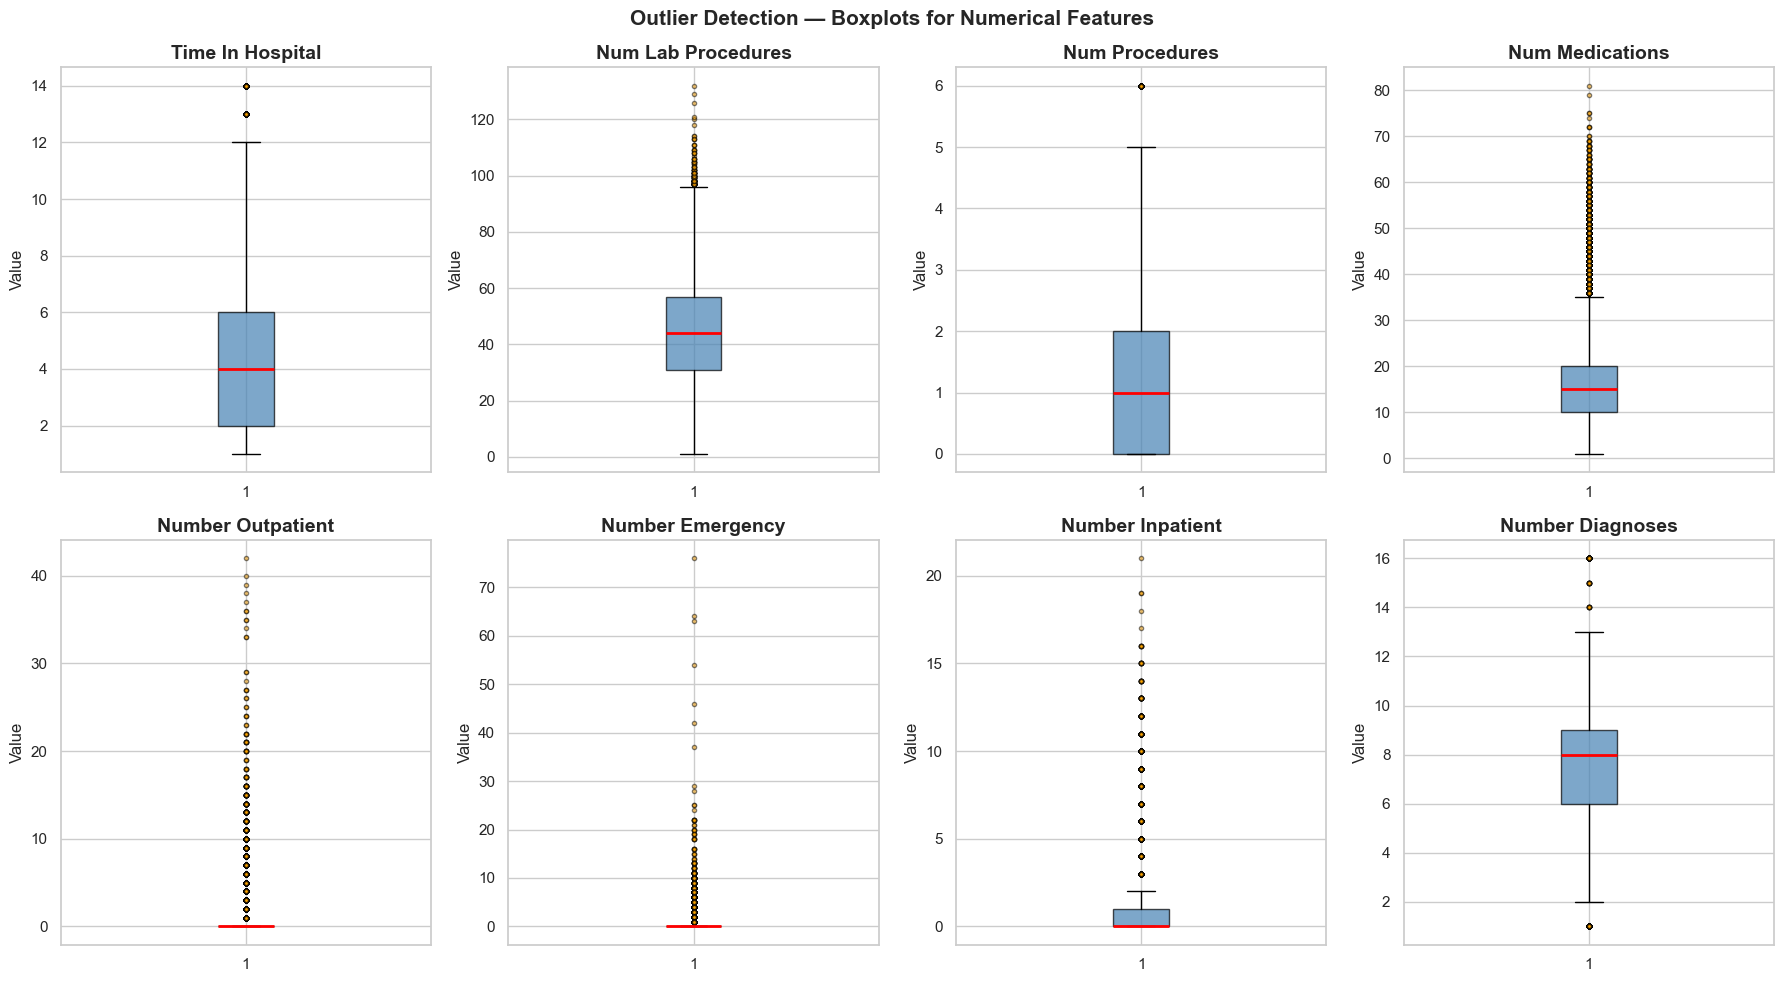

Saved: outliers_boxplot.png


In [11]:
# Cell 11: Boxplots to visualize outliers
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', markerfacecolor='orange',
                                    markersize=3, alpha=0.5))
    axes[i].set_title(col.replace('_', ' ').title())
    axes[i].set_ylabel('Value')

plt.suptitle('Outlier Detection — Boxplots for Numerical Features',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('outliers_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outliers_boxplot.png")

In [12]:
# Cell 12: IQR-based outlier count summary
print("=== Outlier Summary (IQR Method) ===\n")
outlier_summary = []

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    pct = n_outliers / len(df) * 100
    outlier_summary.append({
        'Feature': col,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'Lower Bound': round(lower, 2),
        'Upper Bound': round(upper, 2),
        'Outlier Count': n_outliers,
        'Outlier %': round(pct, 2)
    })

pd.DataFrame(outlier_summary)

=== Outlier Summary (IQR Method) ===



,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,time_in_hospital,2.0,6.0,4.0,-4.0,12.0,2252,2.21
1,num_lab_procedures,31.0,57.0,26.0,-8.0,96.0,143,0.14
2,num_procedures,0.0,2.0,2.0,-3.0,5.0,4954,4.87
3,num_medications,10.0,20.0,10.0,-5.0,35.0,2557,2.51
4,number_outpatient,0.0,0.0,0.0,0.0,0.0,16739,16.45
5,number_emergency,0.0,0.0,0.0,0.0,0.0,11383,11.19
6,number_inpatient,0.0,1.0,1.0,-1.5,2.5,7049,6.93
7,number_diagnoses,6.0,9.0,3.0,1.5,13.5,281,0.28


In [ ]:
# Cell 13: Full EDA Summary Report
report = """
╔══════════════════════════════════════════════════════════════════════╗
║     ReadmitGuard — EDA Report: Patient Readmission Prediction        ║
╚══════════════════════════════════════════════════════════════════════╝

1. DATASET OVERVIEW
───────────────────
- Total encounters : {total:,}
- Total features   : {features}
- Missing values   : Coded as '?' in original data, replaced with NaN
- Target variable  : readmitted  (NO | <30 | >30)

2. DESCRIPTIVE STATISTICS
─────────────────────────
- time_in_hospital   : Avg {avg_time:.1f} days (range: 1–14)
- num_lab_procedures : Avg {avg_lab:.1f} procedures per encounter
- num_medications    : Avg {avg_med:.1f} medications prescribed
- number_diagnoses   : Avg {avg_diag:.1f} diagnoses per encounter
- Skewness detected in number_outpatient, number_emergency, 
  and number_inpatient — indicating most patients have 0 
  prior visits but a small group has many.

3. CATEGORICAL FEATURES
────────────────────────
Race:
- Caucasian patients dominate the dataset (~75%)
- AfricanAmerican is the second largest group (~19%)
- Other groups (Hispanic, Asian, Other) are underrepresented
Gender:
- Roughly balanced: ~54% Female, ~46% Male

4. READMISSION VS AGE
──────────────────────
- Patients aged 70–80 represent the largest group (25.6%)
- 30-day readmission rate peaks in middle-older age groups (60–80)
- Very young patients [0-10) have the fewest encounters and 
  lowest readmission rates
- The dataset skews heavily toward older diabetic patients,
  consistent with the disease's age-related prevalence

5. CORRELATIONS
───────────────
- num_medications and num_lab_procedures show the strongest 
  positive correlation — sicker patients receive more tests and drugs
- number_inpatient shows moderate positive correlation with 
  readmission risk (prior inpatient visits predict future ones)
- time_in_hospital correlates with num_lab_procedures and 
  num_medications, suggesting longer stays = more interventions

6. MEDICATION ANALYSIS
───────────────────────
- ~46% of encounters involved a medication change (change = 'Ch')
- num_medications is roughly normally distributed, centered ~16 meds
- High medication counts (polypharmacy) are a known readmission risk

7. DIAGNOSES
────────────
- Top diagnosis codes: 428 (Heart Failure), 414 (Coronary Artery 
  Disease), 786 (Respiratory Symptoms) — common diabetic comorbidities
- Most patients have 7–9 diagnoses, reflecting high complexity

8. ADMISSION & DISCHARGE PATTERNS
───────────────────────────────────
- Emergency admissions are the most common type (~53%)
- Most patients are discharged to home/self-care
- Emergency Room is the most common admission source
- High emergency admission rates suggest reactive rather than 
  preventive care — a key opportunity for ReadmitGuard

9. OUTLIERS
───────────
- number_outpatient, number_emergency, number_inpatient contain 
  significant right-skewed outliers (most = 0, few = very high)
- These outliers are clinically meaningful (high-utilization patients)
  and should be KEPT in the dataset, not removed
- num_lab_procedures and num_medications have mild outliers 
  consistent with complex or ICU-level patients

10. KEY FINDINGS FOR READMISSION PREDICTION
────────────────────────────────────────────
High-risk patient profile based on EDA:
  ✦ Age 60–80
  ✦ Medicare/Medicaid payer
  ✦ Emergency admission type
  ✦ High number of prior inpatient visits
  ✦ High medication count (polypharmacy)
  ✦ Multiple diagnoses (comorbidities)
  ✦ Medication changes during stay

These features should be prioritized when building the 
ReadmitGuard predictive model.
""".format(
    total=len(df),
    features=df.shape[1],
    avg_time=df['time_in_hospital'].mean(),
    avg_lab=df['num_lab_procedures'].mean(),
    avg_med=df['num_medications'].mean(),
    avg_diag=df['number_diagnoses'].mean()
)

print(report)